In [ ]:
# define custom dataset
import os
import pandas as pd
import numpy as np
from PIL import Image
import torch
from torchvision.io import decode_image
from torch import nn
from torch import optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from datetime import datetime


In [54]:
dir_name = '/kaggle/input/seefoodfhj-2024'
if not os.path.exists(dir_name):
    dir_name = '/workspaces/kaggle-practices/data/seefoodfhj-2024'
os.listdir(dir_name)

['sample_submission.csv',
 'labelnames.csv',
 'train.csv',
 'test.csv',
 'test',
 'train']

In [55]:
train = pd.read_csv(os.path.join(dir_name, 'train.csv'))
train.head()

,id_code,label
0,train1005649,0
1,train1014775,0
2,train1026328,0
3,train1028787,0
4,train1043283,0


([<matplotlib.patches.Wedge at 0x704f7564d490>,
 [Text(1.0994679105269063, 0.03420984831300974, '0'),
  Text(1.0952142828173275, 0.10249719368317949, '1'),
  Text(1.0867234838572613, 0.17038799732709195, '2'),
  Text(1.0740283664388552, 0.23761958691295712, '3'),
  Text(1.0571780303669653, 0.3039319201884266, '4'),
  Text(1.036237684996157, 0.36906836791278297, '5'),
  Text(1.0112883244744026, 0.4327769919736438, '6'),
  Text(0.9824265116730596, 0.4948112257840398, '7'),
  Text(0.9497638852326117, 0.5549311329416062, '8'),
  Text(0.9134268103870881, 0.6129041214301556, '9'),
  Text(0.8735558282377448, 0.668505957304696, '10'),
  Text(0.8303052680974833, 0.7215214215597251, '11'),
  Text(0.7838423752877046, 0.771745509026991, '12'),
  Text(0.7343469945460146, 0.8189838164464764, '13'),
  Text(0.6820105706936774, 0.8630536376506879, '14'),
  Text(0.6270355291214601, 0.9037845126020752, '15'),
  Text(0.5696346626911187, 0.9410187835855222, '16'),
  Text(0.5100299925466691, 0.9746124392305

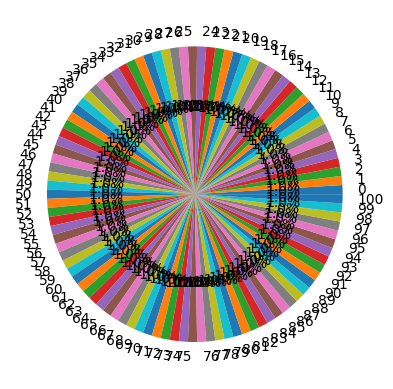

In [56]:
plt.pie(train.groupby('label').size(), labels=list(range(101)), autopct='%1.1f%%')

In [57]:
train_data, test_data = train_test_split(train, test_size=0.2, stratify=train['label'], random_state=42)
train_data.groupby('label').size()

label
0      600
1      600
2      600
3      600
4      600
      ... 
96     600
97     600
98     600
99     600
100    600
Length: 101, dtype: int64

In [58]:
class CustomImageDataset(Dataset):
    def __init__(self, label_data, image_folder, transform=None, target_transform=None):
        self.img_labels = label_data
        self.img_dir = image_folder
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        image_path = os.path.join(self.img_dir, f'{self.img_labels.iloc[idx, 0]}.jpg')
        image = Image.open(image_path).convert('RGB')
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # force all images to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])

# transform = transforms.Compose([
#     transforms.Resize(512),
#     transforms.CenterCrop(512),
#     transforms.ToTensor()
# ])

train_dataset = CustomImageDataset(train_data, f'{dir_name}/train', transform)
test_dataset = CustomImageDataset(test_data, f'{dir_name}/train', transform)


shape of x [N, C, H, W]: torch.Size([128, 3, 224, 224])
Feature batch shape: torch.Size([128, 3, 224, 224])
Labels batch shape: torch.Size([128])


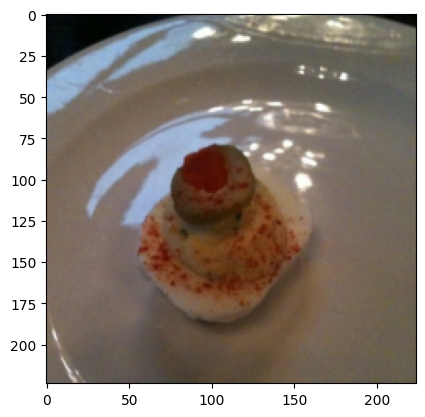

Label: 30


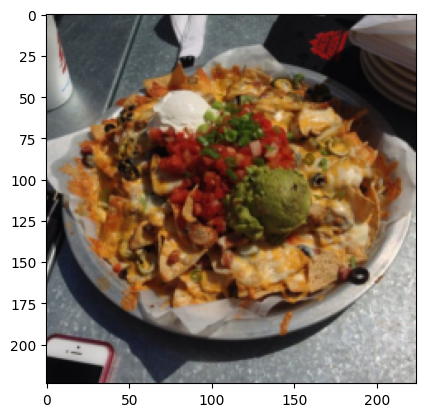

Label: 66


In [60]:
batch_size = 128

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
# for x in train_dataloader:
#   print(f'shape of x [N, C, H, W]: {x.shape}')
#   # print(f'shape of y: {y.shape} {y.dtype}')
#   break

for train_features, train_labels in train_dataloader:
    print(f'shape of x [N, C, H, W]: {train_features.shape}')
    print(f"Feature batch shape: {train_features.size()}")
    print(f"Labels batch shape: {train_labels.size()}")
    for i in range(2):
        label = train_labels[i]
        img = train_features[i]        # shape [3, 224, 224]
        img = img.permute(1, 2, 0)     # now [224, 224, 3]
        plt.imshow(img)
        plt.show()
        print(f"Label: {label}")
    break

In [61]:
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else 'cpu'
print(f'device = {device}')

device = cpu


In [62]:
class ImageCNN(nn.Module):
    def __init__(self, no_channel, no_class):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=no_channel, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(128 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, no_class)
        self.dropout = nn.Dropout(p=0.5)
    
    def forward(self, x):
        x = self.pool(nn.ReLU()(self.conv1(x)))
        x = self.pool(nn.ReLU()(self.conv2(x)))
        x = self.pool(nn.ReLU()(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = ImageCNN(3, 101).to(device)
print(model)


ImageCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=100352, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=101, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [63]:
# Define loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    startTime = datetime.now()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}] tottale time {datetime.now()-startTime}")

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    

In [65]:
for epoch in range(5):
    print(f"Epoch {epoch+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")


Epoch 1
-------------------------------
loss: 4.611190  [    0/60600]
loss: 4.619921  [ 1280/60600]
loss: 4.616460  [ 2560/60600]
loss: 4.620396  [ 3840/60600]
loss: 4.610593  [ 5120/60600]
loss: 4.618992  [ 6400/60600]
loss: 4.617643  [ 7680/60600]
loss: 4.612100  [ 8960/60600]
loss: 4.616672  [10240/60600]
loss: 4.612516  [11520/60600]
loss: 4.615767  [12800/60600]
loss: 4.617700  [14080/60600]
loss: 4.620883  [15360/60600]
loss: 4.617387  [16640/60600]
loss: 4.612870  [17920/60600]
loss: 4.623670  [19200/60600]
loss: 4.617373  [20480/60600]
loss: 4.619254  [21760/60600]
loss: 4.614635  [23040/60600]
loss: 4.620228  [24320/60600]
loss: 4.616206  [25600/60600]
loss: 4.614859  [26880/60600]
loss: 4.612433  [28160/60600]
loss: 4.609186  [29440/60600]
loss: 4.616957  [30720/60600]
loss: 4.614754  [32000/60600]


KeyboardInterrupt: 